In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip -q "/content/drive/MyDrive/GalaxyZoo/galaxy3class.zip" \
       -d "/content/drive/MyDrive/GalaxyZoo/"

In [ ]:
import os

DATA_DIR = "/content/drive/MyDrive/GalaxyZoo"

for root, dirs, files in os.walk(DATA_DIR):
    print(root)
    print("Folders:", dirs)
    print("Example files:", files[:5])
    print("-"*60)

/content/drive/MyDrive/GalaxyZoo
Folders: ['images']
Example files: ['galaxy3class.zip']
------------------------------------------------------------
/content/drive/MyDrive/GalaxyZoo/images
Folders: ['cropped_elliptical', 'cropped_odd', 'cropped_spiral']
Example files: []
------------------------------------------------------------
/content/drive/MyDrive/GalaxyZoo/images/cropped_elliptical
Folders: []
Example files: ['normalized_image_4068.jpg', 'normalized_image_4005.jpg', 'normalized_image_4054.jpg', 'normalized_image_3997.jpg', 'normalized_image_4030.jpg']
------------------------------------------------------------
/content/drive/MyDrive/GalaxyZoo/images/cropped_odd
Folders: []
Example files: ['normalized_image_1510.jpg', 'normalized_image_1498.jpg', 'normalized_image_1445.jpg', 'normalized_image_1439.jpg', 'normalized_image_1418.jpg']
------------------------------------------------------------
/content/drive/MyDrive/GalaxyZoo/images/cropped_spiral
Folders: []
Example files: ['nor

In [ ]:
from torchvision.datasets import ImageFolder

DATA_DIR = "/content/drive/MyDrive/GalaxyZoo/images"

dataset = ImageFolder(DATA_DIR)

print(dataset.classes)
print(len(dataset))

['cropped_elliptical', 'cropped_odd', 'cropped_spiral']
11744


In [ ]:
import os
import copy
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import vgg16, vgg19, VGG16_Weights, VGG19_Weights

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA available: True
GPU: Tesla T4


In [ ]:
from PIL import Image
import glob
import os

paths = glob.glob(os.path.join(DATA_DIR, "*", "*.jpg"))

for p in paths[:10]:
    img = Image.open(p)
    print(os.path.basename(p), img.size)

normalized_image_4068.jpg (150, 150)
normalized_image_4005.jpg (150, 150)
normalized_image_4054.jpg (150, 150)
normalized_image_3997.jpg (250, 250)
normalized_image_4030.jpg (250, 250)
normalized_image_3934.jpg (150, 150)
normalized_image_4071.jpg (150, 150)
normalized_image_4028.jpg (250, 250)
normalized_image_3985.jpg (150, 150)
normalized_image_4001.jpg (150, 150)


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 64
EPOCHS = 5
PATIENCE = 5
LR = 1e-4
WEIGHT_DECAY = 0
SEED = 42
NUM_WORKERS = 2
NUM_CLASSES = 3

In [ ]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

In [ ]:
full_dataset_for_split = ImageFolder(DATA_DIR)

print("Classes:", full_dataset_for_split.classes)
print("Class to index:", full_dataset_for_split.class_to_idx)
print("Total images:", len(full_dataset_for_split))

Classes: ['cropped_elliptical', 'cropped_odd', 'cropped_spiral']
Class to index: {'cropped_elliptical': 0, 'cropped_odd': 1, 'cropped_spiral': 2}
Total images: 11744


In [ ]:
n_total = len(full_dataset_for_split)
n_train = int(0.8 * n_total)
n_val = int(0.1 * n_total)
n_test = n_total - n_train - n_val

generator = torch.Generator().manual_seed(SEED)

train_subset, val_subset, test_subset = random_split(
    full_dataset_for_split,
    [n_train, n_val, n_test],
    generator=generator
)

print("Train:", len(train_subset))
print("Val:", len(val_subset))
print("Test:", len(test_subset))

Train: 9395
Val: 1174
Test: 1175


In [ ]:
train_dataset = ImageFolder(DATA_DIR, transform=train_transform)
eval_dataset = ImageFolder(DATA_DIR, transform=eval_transform)

train_subset.dataset = train_dataset
val_subset.dataset = eval_dataset
test_subset.dataset = eval_dataset

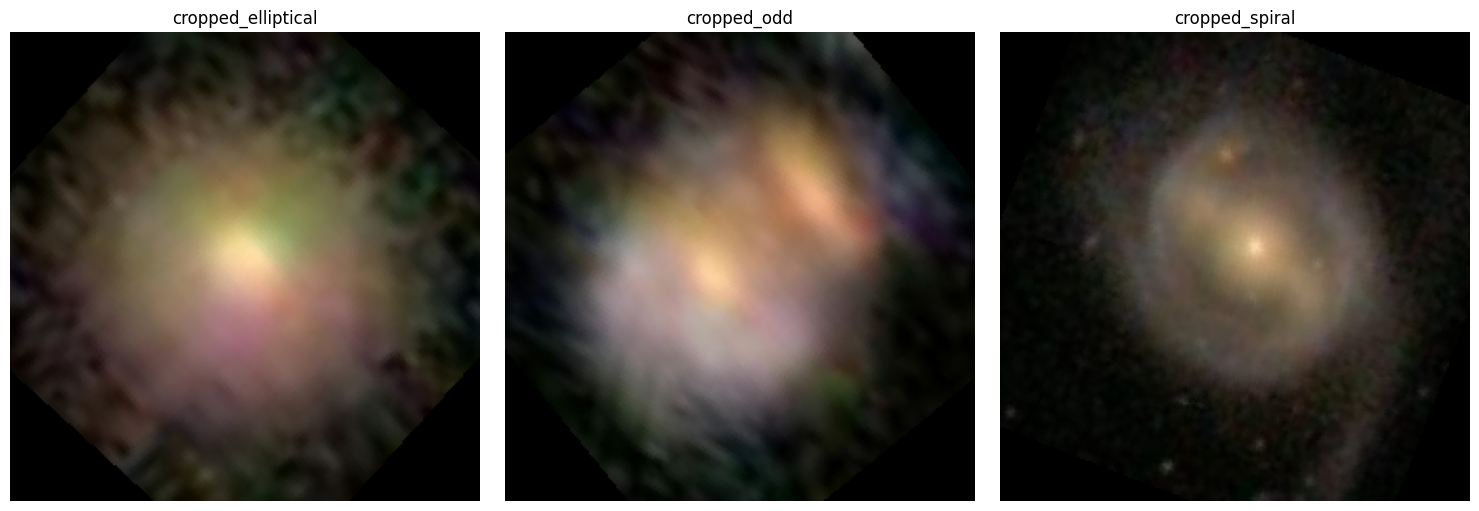

In [ ]:
import matplotlib.pyplot as plt
import torch

class_names = train_subset.dataset.classes

mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

shown = {}

for img, label in train_subset:

    if label not in shown:
        shown[label] = img

    if len(shown) == len(class_names):
        break

fig, axes = plt.subplots(1, len(class_names), figsize=(15,5))

for i, ax in enumerate(axes):

    img = shown[i]

    img = img * std + mean # we undo the normalization here
    img = img.clamp(0,1)

    ax.imshow(img.permute(1,2,0))
    ax.set_title(class_names[i])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

In [ ]:
def build_model(model_name):
    if model_name == "vgg16":
        model = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
    elif model_name == "vgg19":
        model = vgg19(weights=VGG19_Weights.IMAGENET1K_V1)
    else:
        raise ValueError("model_name must be 'vgg16' or 'vgg19'")

    # We will fine-tune all weights
    for param in model.parameters():
        param.requires_grad = True

    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, NUM_CLASSES)

    return model

In [ ]:
def run_one_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.set_grad_enabled(is_train):
        for images, labels in tqdm(loader, leave=False):
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            logits = model(images)
            loss = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            preds = torch.argmax(logits, dim=1)

            total_loss += loss.item() * images.size(0)
            total_correct += (preds == labels).sum().item()
            total_samples += images.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    return avg_loss, avg_acc

In [ ]:
def train_model(model_name):
    print(f"\nTraining {model_name.upper()}")

    model = build_model(model_name).to(DEVICE)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=5
    )

    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
    }

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = run_one_epoch(
            model, train_loader, criterion, optimizer
        )

        val_loss, val_acc = run_one_epoch(
            model, val_loader, criterion, optimizer=None
        )

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch:03d} | "
            f"train loss = {train_loss:.4f} | "
            f"val loss = {val_loss:.4f} | "
            f"train acc = {train_acc:.4f} | "
            f"val acc = {val_acc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0

            save_path = f"/content/best_{model_name}_galaxy3class.pt"
            torch.save(best_state, save_path)

            print(f"Saved best model to {save_path}")
        else:
            patience_counter += 1
            print(f"No improvement. Patience {patience_counter}/{PATIENCE}")

        if patience_counter >= PATIENCE:
            print("Early stopping triggered.")
            break

    model.load_state_dict(best_state)

    test_loss, test_acc = run_one_epoch(
        model, test_loader, criterion, optimizer=None
    )

    print(f"\nFinal test result for {model_name.upper()}:")
    print(f"Test loss = {test_loss:.4f}")
    print(f"Test acc  = {test_acc:.4f}")

    return model, history, {
        "test_loss": test_loss,
        "test_acc": test_acc,
        "best_val_loss": best_val_loss,
    }

In [ ]:
def plot_history(history, model_name):
    plt.figure(figsize=(6, 4))
    plt.plot(history["train_loss"], label="train loss")
    plt.plot(history["val_loss"], label="val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name.upper()} Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(history["train_acc"], label="train accuracy")
    plt.plot(history["val_acc"], label="val accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name.upper()} Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


Training VGG16


Epoch 001 | train loss = 0.2683 | val loss = 0.2790 | train acc = 0.8996 | val acc = 0.9029
Saved best model to /content/best_vgg16_galaxy3class.pt


Epoch 002 | train loss = 0.1396 | val loss = 0.1087 | train acc = 0.9534 | val acc = 0.9625
Saved best model to /content/best_vgg16_galaxy3class.pt


Epoch 003 | train loss = 0.0955 | val loss = 0.0836 | train acc = 0.9686 | val acc = 0.9744
Saved best model to /content/best_vgg16_galaxy3class.pt


Epoch 004 | train loss = 0.0867 | val loss = 0.0892 | train acc = 0.9705 | val acc = 0.9693
No improvement. Patience 1/5


Epoch 005 | train loss = 0.0768 | val loss = 0.0758 | train acc = 0.9742 | val acc = 0.9736
Saved best model to /content/best_vgg16_galaxy3class.pt



Final test result for VGG16:
Test loss = 0.0814
Test acc  = 0.9770


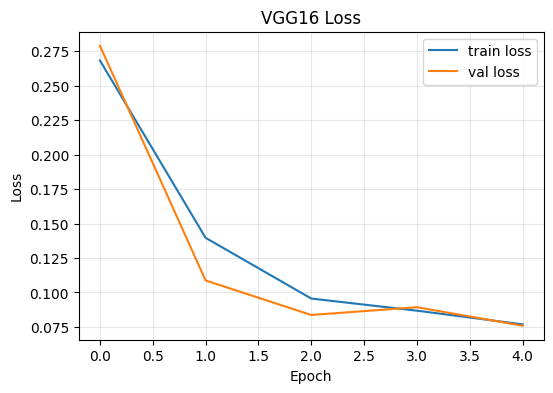

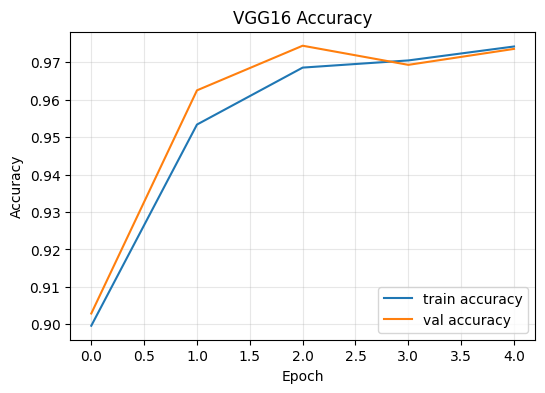


Training VGG19
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:06<00:00, 84.0MB/s]


Epoch 001 | train loss = 0.2718 | val loss = 0.1401 | train acc = 0.8995 | val acc = 0.9583
Saved best model to /content/best_vgg19_galaxy3class.pt


Epoch 002 | train loss = 0.1401 | val loss = 0.1146 | train acc = 0.9533 | val acc = 0.9642
Saved best model to /content/best_vgg19_galaxy3class.pt


Epoch 003 | train loss = 0.1097 | val loss = 0.0943 | train acc = 0.9617 | val acc = 0.9668
Saved best model to /content/best_vgg19_galaxy3class.pt


Epoch 004 | train loss = 0.0953 | val loss = 0.1006 | train acc = 0.9668 | val acc = 0.9634
No improvement. Patience 1/5


Epoch 005 | train loss = 0.0734 | val loss = 0.0869 | train acc = 0.9742 | val acc = 0.9642
Saved best model to /content/best_vgg19_galaxy3class.pt



Final test result for VGG19:
Test loss = 0.0669
Test acc  = 0.9762


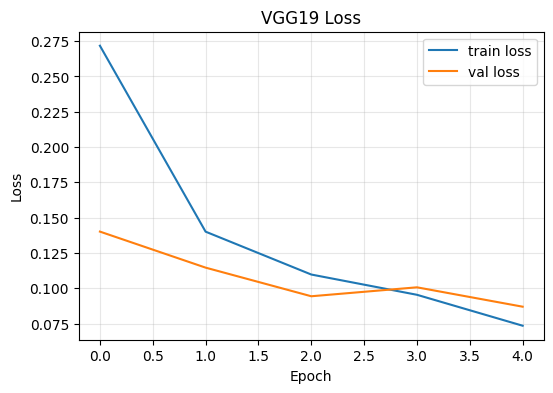

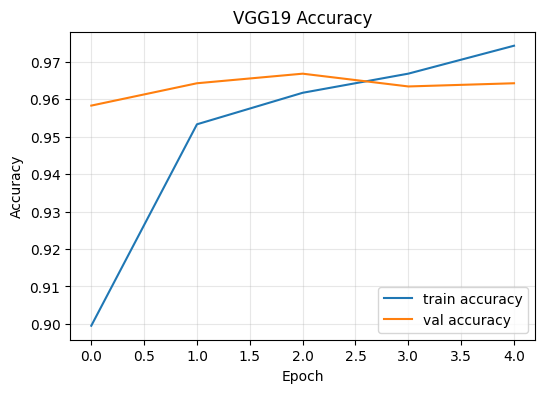

In [ ]:
histories = {}
results = {}

for model_name in ["vgg16"]:
    model, history, test_metrics = train_model(model_name)

    histories[model_name] = history
    results[model_name] = test_metrics

    plot_history(history, model_name)